# Notebook 7 — Does the Plant Bioelectric Signal *Change Together* With CO2, FER, and HRV?

## Research question

> **When CO2, facial-expression valence/arousal, or heart-rate variability
> move up or down, does the plant's bioelectric signal move with them —
> relative to each session's own baseline?**

## Why this notebook exists (and how it differs from `06_Correlation_Analysis.ipynb`)

`06_Correlation_Analysis.ipynb` correlates **absolute values** pooled across
all sessions (e.g. raw `co2_mean` against raw `plant_std`). That is only valid
if the baseline level of each variable is comparable across sessions. It
isn't: CO2 baseline in a room depends on ventilation, time of day, and how
long the door's been closed — it can differ by hundreds of ppm between two
sessions recorded the same afternoon, for reasons that have nothing to do
with the plant or the participant's emotional state. Pooling raw values
across sessions with very different baselines risks either **manufacturing
a spurious correlation** (if baseline happens to trend with something else
across sessions) or **hiding a real one** (if genuine within-session
covariation is swamped by between-session baseline noise).

**This notebook asks a narrower, more defensible question**: not "are the
absolute levels of X and plant signal associated across the whole corpus,"
but **"within a given session, when X goes up or down relative to that
session's own typical level, does the plant signal move with it?"**

Two complementary operationalisations of "change together," both computed
**within each session separately** so between-session baseline differences
cannot contaminate the result:

1. **Relative-level covariation** — robust (median/MAD) z-score every
   variable *within its own session*, removing that session's baseline
   entirely, then correlate the z-scores pooled across sessions. This keeps
   the full time resolution and any slow within-session trend shape.
2. **Moment-to-moment change covariation** — subsample to **non-overlapping**
   30-second windows within each session (the consolidated dataset's windows
   overlap 83%, which would otherwise dominate a difference-based measure),
   take the **first difference** between consecutive non-overlapping windows,
   then correlate the deltas pooled across sessions. This is the strictest
   reading of "change together": it removes not just the baseline level but
   any slow trend, isolating whether *fluctuations* co-occur.

If both approaches agree, that's reasonably strong evidence of real
within-session coupling. If they disagree, the relative-level version is
more sensitive to slow co-drift while the difference version is stricter
about instantaneous coupling — the gap itself is informative.

## The three relationships requested

| Driver | Plant target |
|---|---|
| **CO2** (`co2_mean`) | bioelectric features |
| **FER** (`fer_valence`, `fer_arousal`) | bioelectric features |
| **HRV / RMSSD** (`rmssd`, `mean_hr`, `sdnn`, `pnn50`) | bioelectric features |

"Bioelectric features" = the same `plant_*` / `bp_*` feature set used
throughout this project (`plant_mean`, `plant_std`, `plant_rms`, spectral
band powers, etc.).

## Statistical conventions (kept identical to `06_Correlation_Analysis.ipynb`)

- **Pearson** if both variables are approximately normal (Shapiro-Wilk),
  else **Spearman** as the primary coefficient; **Kendall τ** always also
  reported (small-sample robustness).
- **Benjamini-Hochberg FDR correction** applied within each analysis family
  (CO2 / FER / HRV), separately for the z-score approach and the diff
  approach, at α = 0.05.
- Effect size (Cohen): <0.10 negligible, 0.10-0.29 small, 0.30-0.49
  moderate, ≥0.50 large.

## Honest caveat up front

This dataset is **one participant, 15 sessions, all recorded the same
afternoon** (established in earlier analysis). "Within-session" normalisation
is therefore the *only* meaningful grouping available here — there is no
cross-participant generalisation to claim either way. A significant result
here means "in this person's data, on this day, X and the plant signal moved
together relative to each session's own baseline" — a real, checkable
finding, but not evidence the relationship holds for plants or people in
general.


## 1  Imports & Configuration

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

try:
    from statsmodels.stats.multitest import multipletests
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("statsmodels not installed - FDR correction disabled (pip install statsmodels).")

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════
DATASET_CSV = Path("./consolidated_dataset.csv")   # output of 04_dataset_creation.ipynb

# Must match the classifier's window geometry (03_ground_truth_classifier.ipynb)
WIN_S  = 30
STEP_S = 5
NONOVERLAP_STEP_WINDOWS = max(1, int(round(WIN_S / STEP_S)))  # rows to skip for non-overlapping windows

ALPHA           = 0.05
NORMALITY_ALPHA = 0.05
RANDOM_STATE    = 42

SESSION_COL = "session_id"
ORDER_COL   = "win_start_ms"

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print(f"Dataset                   : {DATASET_CSV.resolve()}")
print(f"Non-overlapping step      : every {NONOVERLAP_STEP_WINDOWS} rows "
      f"({WIN_S}s window / {STEP_S}s step)")
print(f"statsmodels               : {STATSMODELS_OK}")


Dataset                   : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\consolidated_dataset.csv
Non-overlapping step      : every 6 rows (30s window / 5s step)
statsmodels               : True


## 2  Load Data & Define Variable Groups

In [2]:

if not DATASET_CSV.exists():
    raise FileNotFoundError(f"{DATASET_CSV.resolve()} not found. Run 04_dataset_creation.ipynb first.")

df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")

if "label" in df.columns:
    df = df[df["label"] != "excluded"].copy()

if SESSION_COL not in df.columns:
    raise RuntimeError(f"'{SESSION_COL}' column not found - this notebook needs the "
                       "provenance-tagged consolidated dataset (session_id per row).")

print(f"Sessions: {df[SESSION_COL].nunique()}  |  Usable rows: {len(df)}")

co2_col  = "co2_mean"
fer_cols = [c for c in ["fer_valence", "fer_arousal"] if c in df.columns]
hrv_cols = [c for c in ["rmssd", "mean_hr", "sdnn", "pnn50"] if c in df.columns]

plant_features = [c for c in [
    "plant_mean","plant_median","plant_std","plant_iqr","plant_min","plant_max",
    "plant_range","plant_rms","plant_zcr",
    "bp_0_1","bp_1_5","bp_5_15","bp_15_30","bp_30_50","total_power"
] if c in df.columns]

print(f"\nCO2 driver        : {co2_col if co2_col in df.columns else 'MISSING'}")
print(f"FER drivers       : {fer_cols}")
print(f"HRV/RMSSD drivers : {hrv_cols}")
print(f"Bioelectric targets ({len(plant_features)}): {plant_features}")


Loaded 1690 rows x 42 columns
Sessions: 15  |  Usable rows: 1690

CO2 driver        : co2_mean
FER drivers       : ['fer_valence', 'fer_arousal']
HRV/RMSSD drivers : ['rmssd', 'mean_hr', 'sdnn', 'pnn50']
Bioelectric targets (15): ['plant_mean', 'plant_median', 'plant_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'bp_30_50', 'total_power']


## 3  Two Ways of Removing the Session Baseline

`within_session_zscore` centers and scales every variable **per session**
using the robust median/MAD estimator already used throughout this project
(same convention as the HRV/FER normalisation in `03_ground_truth_classifier.ipynb`),
so a session with CO2 sitting at 1800ppm and one sitting at 500ppm both end
up on the same relative scale.

`make_nonoverlapping_diff` first **thins each session to non-overlapping
windows** (taking every `NONOVERLAP_STEP_WINDOWS`-th row — the consolidated
dataset's windows are 30s wide but only 5s apart, so consecutive rows share
25 of 30 seconds; differencing them directly would mostly cancel out and
tell you nothing), then takes the **first difference** of each column within
each session. Differences are never taken across a session boundary.


In [3]:

def within_session_zscore(frame, cols, session_col=SESSION_COL):
    # Robust (median/MAD) z-score each column within each session.
    out = frame.copy()
    for col in cols:
        def _z(s):
            x = pd.to_numeric(s, errors="coerce")
            c = x.median()
            scale = 1.4826 * (x - c).abs().median()
            if not np.isfinite(scale) or scale == 0:
                return x - c
            return (x - c) / scale
        out[col] = out.groupby(session_col)[col].transform(_z)
    return out


def make_nonoverlapping_diff(frame, cols, session_col=SESSION_COL, order_col=ORDER_COL,
                             step_windows=NONOVERLAP_STEP_WINDOWS):
    # Thin each session to non-overlapping windows, then first-difference.
    rows = []
    for sid, g in frame.sort_values(order_col).groupby(session_col):
        g = g.iloc[::step_windows].reset_index(drop=True)
        if len(g) < 2:
            continue
        d = g[cols].apply(pd.to_numeric, errors="coerce").diff()
        d[session_col] = sid
        d[order_col] = g[order_col]
        rows.append(d.iloc[1:])
    if not rows:
        return pd.DataFrame(columns=cols + [session_col, order_col])
    return pd.concat(rows, ignore_index=True)


all_drivers = ([co2_col] if co2_col in df.columns else []) + fer_cols + hrv_cols
all_cols    = all_drivers + plant_features

df_z    = within_session_zscore(df, all_cols)
df_diff = make_nonoverlapping_diff(df, all_cols)

print(f"z-scored dataset   : {len(df_z)} rows (same as input, transformed in place)")
print(f"differenced dataset: {len(df_diff)} rows "
      f"(thinned to non-overlapping windows, first row per session dropped)")


z-scored dataset   : 1690 rows (same as input, transformed in place)
differenced dataset: 268 rows (thinned to non-overlapping windows, first row per session dropped)


### 3.1  Why This Matters — a Concrete Illustration

Before running any statistics: a direct visual check that session baselines
really do differ enough to justify this whole approach. Two sessions' raw
CO2 traces, side by side with their within-session z-scores.


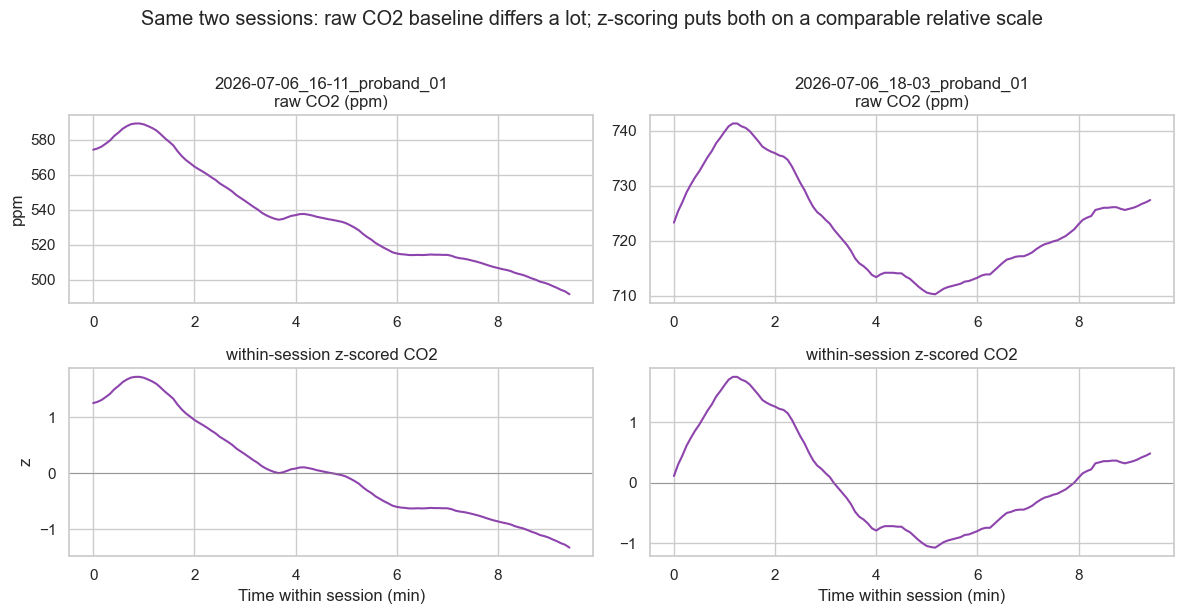

Raw CO2 median per session (first 5 sessions):
session_id
2026-07-06_16-11_proband_01    534.20
2026-07-06_16-25_proband_01    557.30
2026-07-06_16-39_proband_01    494.65
2026-07-06_16-54_proband_01    521.25
2026-07-06_17-20_proband_01    911.55
Name: co2_mean, dtype: float64


In [4]:

sessions_present = sorted(df[SESSION_COL].unique())
example_sessions = [sessions_present[0], sessions_present[len(sessions_present)//2]]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=False)
for col_i, sid in enumerate(example_sessions):
    sub_raw = df[df[SESSION_COL] == sid].sort_values(ORDER_COL)
    sub_z   = df_z[df_z[SESSION_COL] == sid].sort_values(ORDER_COL)
    t_min = (sub_raw[ORDER_COL] - sub_raw[ORDER_COL].min()) / 60_000

    axes[0, col_i].plot(t_min, sub_raw[co2_col], color="#8e44ad")
    axes[0, col_i].set_title(f"{sid}\nraw CO2 (ppm)")
    axes[0, col_i].set_xlabel("")

    axes[1, col_i].plot(t_min, sub_z[co2_col], color="#8e44ad")
    axes[1, col_i].axhline(0, color="gray", lw=0.5)
    axes[1, col_i].set_title("within-session z-scored CO2")
    axes[1, col_i].set_xlabel("Time within session (min)")

axes[0,0].set_ylabel("ppm"); axes[1,0].set_ylabel("z")
plt.suptitle("Same two sessions: raw CO2 baseline differs a lot; "
            "z-scoring puts both on a comparable relative scale", y=1.02)
plt.tight_layout(); plt.show()

print("Raw CO2 median per session (first 5 sessions):")
print(df.groupby(SESSION_COL)[co2_col].median().head())


## 4  Statistical Engine (shared across all three driver families)

In [5]:

def effect_label(coef):
    a = abs(coef)
    if np.isnan(a): return "n/a"
    if a < 0.10:    return "negligible"
    if a < 0.30:    return "small"
    if a < 0.50:    return "moderate"
    return "large"

def is_normal(x, alpha=NORMALITY_ALPHA):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    if len(x) < 3 or np.std(x) == 0:
        return False
    xs = x if len(x) <= 5000 else np.random.choice(x, 5000, replace=False)
    try:
        _, p = stats.shapiro(xs)
    except Exception:
        return False
    return p > alpha

def valid_pairs(frame, a, b):
    sub = frame[[a, b]].apply(pd.to_numeric, errors="coerce").dropna()
    return sub[a].values, sub[b].values

def correlation_test(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    if n < 8 or np.std(x) == 0 or np.std(y) == 0:
        return dict(n=n, primary_method="n/a", primary_r=np.nan, primary_p=np.nan,
                    pearson_r=np.nan, pearson_p=np.nan, spearman_r=np.nan, spearman_p=np.nan,
                    kendall_tau=np.nan, kendall_p=np.nan, effect="n/a")
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    kt, kp = stats.kendalltau(x, y)
    use_pearson = is_normal(x) and is_normal(y)
    out = dict(n=n, primary_method="Pearson" if use_pearson else "Spearman",
               primary_r=pr if use_pearson else sr, primary_p=pp if use_pearson else sp,
               pearson_r=pr, pearson_p=pp, spearman_r=sr, spearman_p=sp,
               kendall_tau=kt, kendall_p=kp)
    out["effect"] = effect_label(out["primary_r"])
    return out

def fdr_adjust(pvals):
    p = np.asarray(pvals, float)
    mask = ~np.isnan(p)
    adj = np.full_like(p, np.nan)
    if mask.sum() == 0:
        return adj
    if STATSMODELS_OK:
        adj[mask] = multipletests(p[mask], method="fdr_bh")[1]
    else:
        adj[mask] = p[mask]
    return adj

def run_family(frame, drivers, targets, family_name):
    # All driver x target pairs for one family (CO2 / FER / HRV), FDR-corrected
    # within the family. Returns a tidy DataFrame.
    rows = []
    for drv in drivers:
        for tgt in targets:
            xv, yv = valid_pairs(frame, drv, tgt)
            res = correlation_test(xv, yv)
            rows.append({"driver": drv, "target": tgt, **res})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_adj"] = fdr_adjust(out["primary_p"].values)
        out["significant"] = out["p_adj"] < ALPHA
        out["family"] = family_name
        out = out.sort_values("primary_p", na_position="last").reset_index(drop=True)
    return out

print("Statistical engine ready.")


Statistical engine ready.


## 5  CO2 to Bioelectric Signal

Both the **relative-level** (z-scored) and **moment-to-moment change**
(non-overlapping first-difference) versions, run against every plant
feature.

In [6]:

results = {}

if co2_col in df.columns:
    print("="*70); print("  CO2 -> BIOELECTRIC SIGNAL  (relative-level, z-scored)"); print("="*70)
    res_z = run_family(df_z, [co2_col], plant_features, "CO2 (z-scored levels)")
    results["co2_z"] = res_z
    show = res_z[["target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
    show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
    print(show.to_string(index=False))
    print(f"\nSignificant (FDR): {int(res_z['significant'].sum())}/{len(res_z)}\n")

    print("="*70); print("  CO2 -> BIOELECTRIC SIGNAL  (moment-to-moment change)"); print("="*70)
    res_d = run_family(df_diff, [co2_col], plant_features, "CO2 (first difference)")
    results["co2_diff"] = res_d
    show = res_d[["target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
    show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
    print(show.to_string(index=False))
    print(f"\nSignificant (FDR): {int(res_d['significant'].sum())}/{len(res_d)}\n")
else:
    print("co2_mean not present in dataset - skipping CO2 analysis.")


  CO2 -> BIOELECTRIC SIGNAL  (relative-level, z-scored)
      target primary_method  primary_r  primary_p  p_adj     effect  significant    n
   plant_rms       Spearman    -0.1336     0.0000 0.0000      small         True 1690
    bp_15_30       Spearman    -0.1164     0.0000 0.0000      small         True 1690
   plant_zcr       Spearman    -0.1128     0.0000 0.0000      small         True 1690
   plant_std       Spearman    -0.1080     0.0000 0.0000      small         True 1690
     bp_5_15       Spearman    -0.1011     0.0000 0.0001      small         True 1690
  plant_mean       Spearman    -0.0916     0.0002 0.0004 negligible         True 1690
   plant_max       Spearman    -0.0885     0.0003 0.0006 negligible         True 1690
   plant_iqr       Spearman    -0.0827     0.0007 0.0012 negligible         True 1690
    bp_30_50       Spearman    -0.0814     0.0008 0.0013 negligible         True 1690
      bp_0_1       Spearman     0.0647     0.0078 0.0116 negligible         True 169

## 6  FER (Valence & Arousal) to Bioelectric Signal

In [7]:

print("="*70); print("  FER -> BIOELECTRIC SIGNAL  (relative-level, z-scored)"); print("="*70)
res_z = run_family(df_z, fer_cols, plant_features, "FER (z-scored levels)")
results["fer_z"] = res_z
show = res_z[["driver","target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
print(show.to_string(index=False))
print(f"\nSignificant (FDR): {int(res_z['significant'].sum())}/{len(res_z)}\n")

print("="*70); print("  FER -> BIOELECTRIC SIGNAL  (moment-to-moment change)"); print("="*70)
res_d = run_family(df_diff, fer_cols, plant_features, "FER (first difference)")
results["fer_diff"] = res_d
show = res_d[["driver","target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
print(show.to_string(index=False))
print(f"\nSignificant (FDR): {int(res_d['significant'].sum())}/{len(res_d)}\n")


  FER -> BIOELECTRIC SIGNAL  (relative-level, z-scored)


     driver       target primary_method  primary_r  primary_p  p_adj     effect  significant    n
fer_arousal    plant_iqr       Spearman     0.2025     0.0000 0.0000      small         True 1690
fer_valence     bp_30_50       Spearman    -0.1858     0.0000 0.0000      small         True 1690
fer_arousal    plant_std       Spearman     0.1722     0.0000 0.0000      small         True 1690
fer_valence       bp_1_5       Spearman     0.1556     0.0000 0.0000      small         True 1690
fer_valence    plant_std       Spearman    -0.1495     0.0000 0.0000      small         True 1690
fer_valence    plant_max       Spearman    -0.1379     0.0000 0.0000      small         True 1690
fer_arousal  plant_range       Spearman     0.1290     0.0000 0.0000      small         True 1690
fer_arousal    plant_max       Spearman     0.1177     0.0000 0.0000      small         True 1690
fer_arousal    plant_min       Spearman    -0.1150     0.0000 0.0000      small         True 1690
fer_arousal     bp_3

## 7  HRV / RMSSD to Bioelectric Signal

In [8]:

print("="*70); print("  HRV/RMSSD -> BIOELECTRIC SIGNAL  (relative-level, z-scored)"); print("="*70)
res_z = run_family(df_z, hrv_cols, plant_features, "HRV (z-scored levels)")
results["hrv_z"] = res_z
show = res_z[["driver","target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
print(show.to_string(index=False))
print(f"\nSignificant (FDR): {int(res_z['significant'].sum())}/{len(res_z)}\n")

print("="*70); print("  HRV/RMSSD -> BIOELECTRIC SIGNAL  (moment-to-moment change)"); print("="*70)
res_d = run_family(df_diff, hrv_cols, plant_features, "HRV (first difference)")
results["hrv_diff"] = res_d
show = res_d[["driver","target","primary_method","primary_r","primary_p","p_adj","effect","significant","n"]].copy()
show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
print(show.to_string(index=False))
print(f"\nSignificant (FDR): {int(res_d['significant'].sum())}/{len(res_d)}\n")


  HRV/RMSSD -> BIOELECTRIC SIGNAL  (relative-level, z-scored)


 driver       target primary_method  primary_r  primary_p  p_adj     effect  significant    n
  rmssd    plant_iqr       Spearman    -0.1632     0.0000 0.0000      small         True 1690
mean_hr plant_median       Spearman     0.1525     0.0000 0.0000      small         True 1690
  rmssd    plant_std       Spearman    -0.1462     0.0000 0.0000      small         True 1690
   sdnn    plant_iqr       Spearman    -0.1274     0.0000 0.0000      small         True 1690
  pnn50    plant_iqr       Spearman    -0.1251     0.0000 0.0000      small         True 1690
  pnn50    plant_std       Spearman    -0.1203     0.0000 0.0000      small         True 1690
mean_hr       bp_1_5       Spearman     0.1094     0.0000 0.0001      small         True 1690
mean_hr    plant_zcr       Spearman    -0.0998     0.0000 0.0003 negligible         True 1690
   sdnn    plant_std       Spearman    -0.0929     0.0001 0.0009 negligible         True 1690
  pnn50    plant_zcr       Spearman     0.0809     0.0009 0.

## 8  Visual Summary — Correlation Heatmaps

Two heatmaps of the full driver x plant-feature correlation coefficient
matrix (Spearman, for uniformity across both normal and non-normal
variables): one for the z-scored (relative-level) view, one for the
differenced (moment-to-moment) view. Placed side by side so agreement or
disagreement between the two operationalisations of "change together" is
visible at a glance.


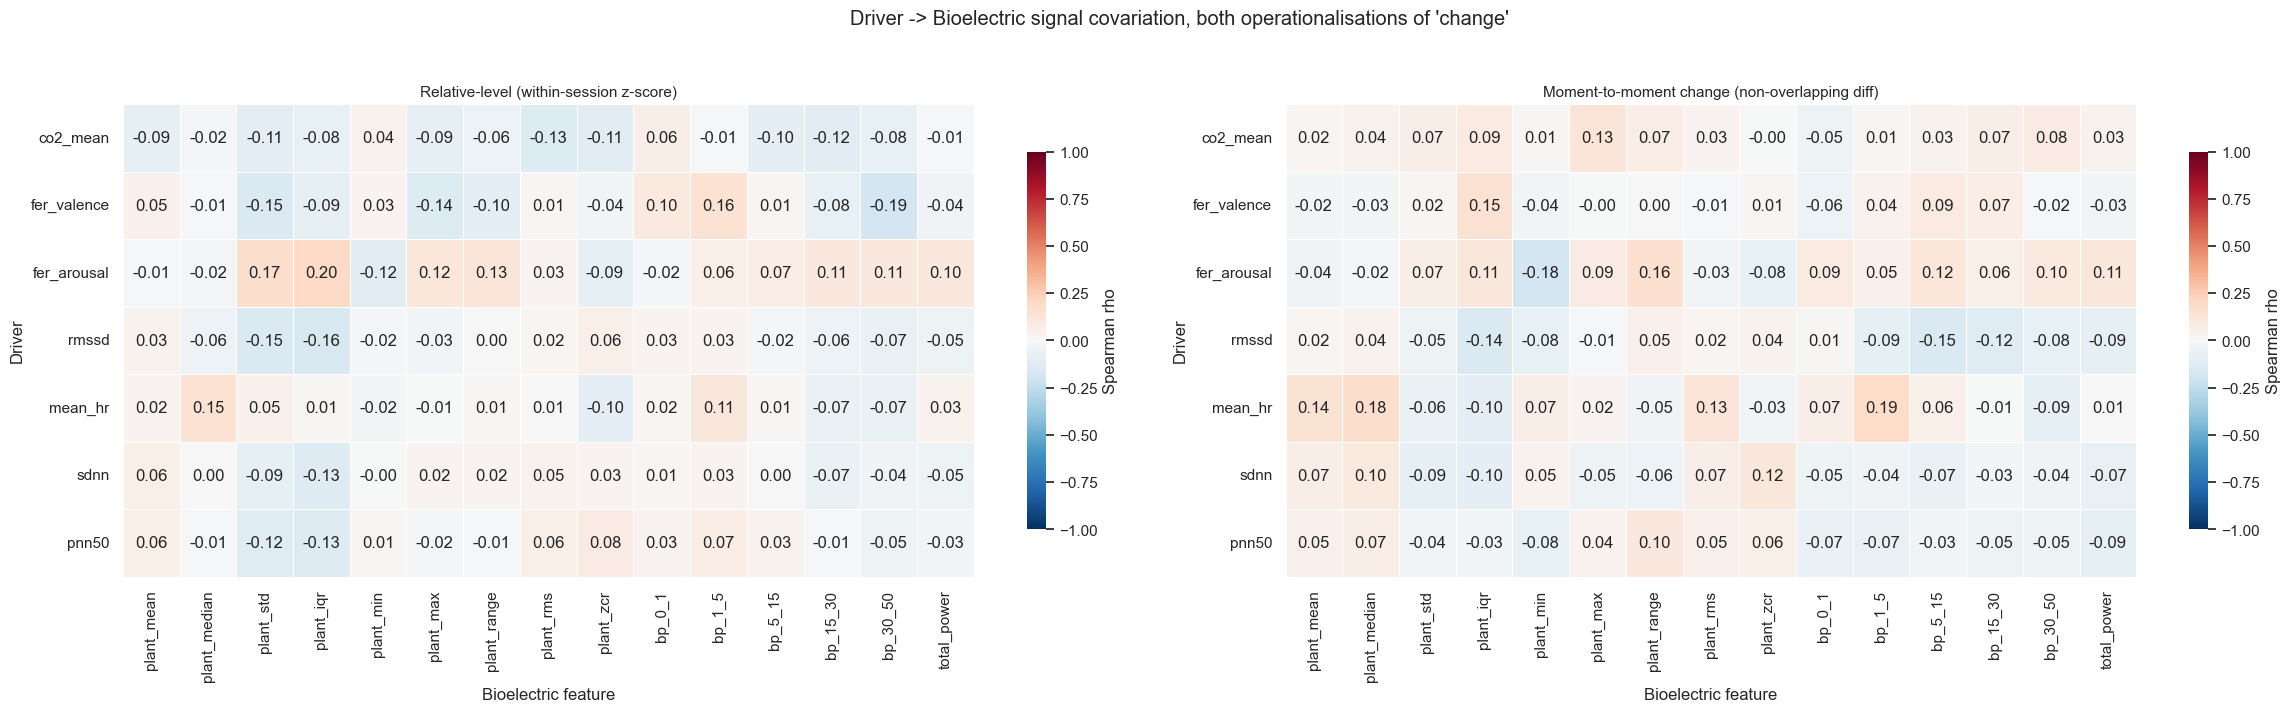

In [9]:

def corr_matrix(frame, drivers, targets, method="spearman"):
    cols = drivers + targets
    mat = frame[cols].apply(pd.to_numeric, errors="coerce")
    full = mat.corr(method=method)
    return full.loc[drivers, targets]

drivers_all = ([co2_col] if co2_col in df.columns else []) + fer_cols + hrv_cols

mat_z    = corr_matrix(df_z, drivers_all, plant_features)
mat_diff = corr_matrix(df_diff, drivers_all, plant_features)

fig, axes = plt.subplots(1, 2, figsize=(1.05*len(plant_features)+8, 0.7*len(drivers_all)+2))
for ax, mat, title in zip(axes, [mat_z, mat_diff],
                          ["Relative-level (within-session z-score)",
                           "Moment-to-moment change (non-overlapping diff)"]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                linewidths=0.5, cbar_kws={"label":"Spearman rho","shrink":0.8}, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Bioelectric feature"); ax.set_ylabel("Driver")
plt.suptitle("Driver -> Bioelectric signal covariation, both operationalisations of 'change'", y=1.03)
plt.tight_layout(); plt.show()


## 9  Results Summary

In [10]:

summary = pd.concat([v for v in results.values() if not v.empty], ignore_index=True)
summary_display = summary[["family","driver","target","primary_method","primary_r",
                           "primary_p","p_adj","effect","significant","n"]].copy()
summary_display[["primary_r","primary_p","p_adj"]] = summary_display[["primary_r","primary_p","p_adj"]].round(4)

print("Significant relationships only (FDR-adjusted, alpha=%.2f):\n" % ALPHA)
sig_only = summary_display[summary_display["significant"]].sort_values("p_adj")
print(sig_only.to_string(index=False) if len(sig_only) else "  (none)")

OUT_CSV = "correlation_results_change.csv"
summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results ({len(summary)} tests across all families) to {OUT_CSV}")
print(f"Total significant after FDR: {int(summary['significant'].sum())}/{len(summary)}")


Significant relationships only (FDR-adjusted, alpha=0.05):

               family      driver       target primary_method  primary_r  primary_p  p_adj     effect  significant    n
CO2 (z-scored levels)    co2_mean    plant_rms       Spearman    -0.1336     0.0000 0.0000      small         True 1690
CO2 (z-scored levels)    co2_mean     bp_15_30       Spearman    -0.1164     0.0000 0.0000      small         True 1690
CO2 (z-scored levels)    co2_mean    plant_zcr       Spearman    -0.1128     0.0000 0.0000      small         True 1690
CO2 (z-scored levels)    co2_mean    plant_std       Spearman    -0.1080     0.0000 0.0000      small         True 1690
FER (z-scored levels) fer_valence     bp_30_50       Spearman    -0.1858     0.0000 0.0000      small         True 1690
FER (z-scored levels) fer_arousal    plant_std       Spearman     0.1722     0.0000 0.0000      small         True 1690
FER (z-scored levels) fer_valence       bp_1_5       Spearman     0.1556     0.0000 0.0000      smal

## 10  Interpretation & Limitations

### How to read the two operationalisations together
- **Z-scored (relative-level) significant, diff not**: the plant feature and
  the driver tend to sit at correspondingly high/low levels across a session
  (e.g. both drift upward together over the 10 minutes), but their
  moment-to-moment jitter isn't coupled. Consistent with a shared slow trend
  (e.g. both responding to elapsed time or room conditions) rather than
  tight coupling.
- **Diff significant, z-scored not**: fluctuations track together
  instantaneously but there's no consistent relative-level relationship —
  less common, would suggest a fast coupling without a shared trend.
- **Both significant**: the strongest evidence available in this dataset that
  the two genuinely move together, at multiple time scales.
- **Neither significant**: no detectable within-session covariation by either
  measure — the honest reading is that this dataset doesn't show the plant
  signal changing together with that driver, not that it's disproven for
  plants/emotion in general (see sample-size caveat below).

### Confounds to keep in mind
- **CO2** accumulates with time in a closed room regardless of anyone's
  emotional state; if CO2 and a plant feature both drift with elapsed
  session time, this analysis will report covariation without it being a
  causal plant-CO2 relationship — elapsed time is a plausible shared driver
  for both.
- **HRV/RMSSD** primarily reflects arousal, not valence (see
  `03_ground_truth_classifier.ipynb` for the underlying evidence) — a
  significant RMSSD-plant relationship says something about arousal-linked
  covariation, not necessarily "emotion."
- **FER** here is a per-window confidence-weighted average across detected
  faces; low-confidence windows are included in this analysis (unlike the
  ground-truth labelling, which discounts them) — worth re-running restricted
  to `fer_confidence` above some threshold if a result looks promising.

### Sample-size and independence caveats (same as `06_Correlation_Analysis.ipynb`)
- **One participant, 15 sessions, one afternoon.** No cross-subject or
  cross-day generalisation claim is supported by this data regardless of
  what the numbers show.
- **Even after non-overlap thinning**, consecutive windows within a session
  are not fully independent (physiological and environmental signals have
  their own autocorrelation beyond the sampling window itself) — treat p-values
  as indicative, not as a guarantee against inflated significance.
- A **linear mixed-effects model** (session as random effect, driver as fixed
  effect) would be the natural next step to formally account for the
  repeated-measures structure instead of relying on within-session
  normalisation as a proxy for it.

### Relation to `06_Correlation_Analysis.ipynb`
That notebook establishes whether **absolute levels** across the whole
corpus are associated (useful as a first pass and for comparison against
this notebook — if `06` finds a correlation this notebook doesn't replicate
after removing session baseline, that correlation was very likely a
between-session confound, not a real within-session relationship).

---

*All statistics reproducible from `consolidated_dataset.csv`. Full results
saved to `correlation_results_change.csv`.*
